   Age  Salary  Past_Purchase  Purchased
0   22   25000              1          0
1   25   30000              2          0
2   28   35000              3          0
3   30   40000              4          0
4   32   45000              5          1
             Age        Salary  Past_Purchase  Purchased
count  20.000000     20.000000      20.000000  20.000000
mean   33.350000  46650.000000       5.100000   0.550000
std     7.095403  14239.585299       2.845125   0.510418
min    22.000000  25000.000000       1.000000   0.000000
25%    27.750000  34500.000000       2.750000   0.000000
50%    33.000000  46500.000000       5.000000   1.000000
75%    39.250000  58500.000000       7.250000   1.000000
max    45.000000  70000.000000      10.000000   1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            20 non-null     int64
 1   Salary  

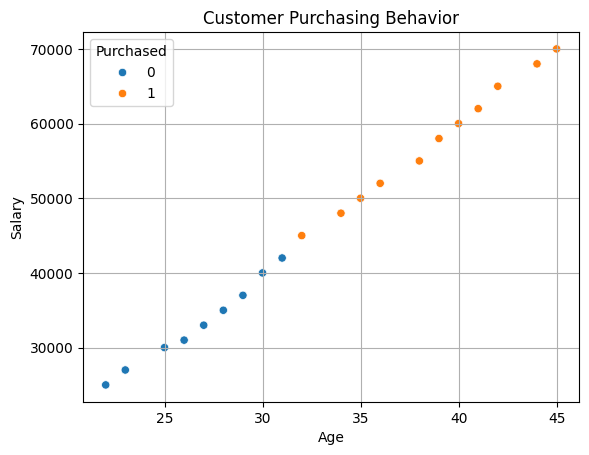

C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Confusion Matrix : 
0.75
Customer  will not purchase (Not Target)


C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
# Step 1 : Import required libraries
import numpy as np                # numerical operations
import pandas as pd               # data manipulation
import matplotlib.pyplot as plt   # Plotting 
import seaborn as sns             # Advanced visulization 

from sklearn.model_selection import train_test_split # data splitting 
from sklearn.neighbors import KNeighborsClassifier # KNN Model

# Step 2: Data Loading and Exploration
# Load the dataset 
df = pd.read_csv("customer_data.csv")

# Step 3 : Understanding the data
# Display the first few rows of the dataset
print(df.head())
# Statistical summary of the dataset
print(df.describe())
# check column names and data types
print(df.info())

# Step 4 : Data Cleaning and Preprocessing
# Check for missing values
print(df.isnull().sum())
# Check  for duplicate values
print(df.duplicated().sum()) 

# Step 5 : Features and Target Splitting
X = df[["Age", "Salary"]]
y = df[["Purchased"]]

# Step 6 : Visualization
# Scatter plot of Age vs Salary colored by Purchased
sns.scatterplot(x = "Age", y = "Salary", hue= "Purchased", data=df)
plt.title("Customer Purchasing Behavior")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid()
plt.savefig("images/visualization.png")
plt.show()

# Step 7 : Train Test Split for model evaluation
X_train, X_test , y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42)

# Step 8 : Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train) # training data scale
X_test = sc.fit_transform(X_test) # testing data scaling

# Step 9: Intialize KNN Model 
model = KNeighborsClassifier(n_neighbors=5) # K=5 neighbors

# Step 10: Train model 
model.fit(X_train , y_train) # model training 

# Step 11: Predictions
y_pred = model.predict(X_test) # test data model prediction

# Step 12 : Evaluate Model 
from sklearn.metrics import confusion_matrix, accuracy_score
print("Confusion Matrix : ")
print(accuracy_score(y_test , y_pred))

# Step 13 :  User Input 
age = int(input("Enter the Age : "))
salary = int(input("Enter the Salary : "))

# User convert in input array
user_data = np.array([[age , salary]])

# apply same scaling
user_data = sc.transform(user_data) 

# Step No 14: Prediction 
result = model.predict(user_data)

# Step No 15 : Final Output 
if result[0] == 1 :
    print("Customer will purchase (Target Customer )")
else:
    print("Customer  will not purchase (Not Target)")

